

В этом домашнем задании вам предстоит обучить DCGAN для генерации лиц и изучить латентное пространство. Модель DCGAN аналогична той, которая использовалась на лекции. Рекомендуем вам подробно ознакомится с приведенным кодом, чтобы лучше понимать как все устроено “изнутри”.


В качестве напоминания приводим ниже иллюстрацию архитектуры ([источник](https://github.com/znxlwm/tensorflow-MNIST-GAN-DCGAN) иллюстрации).

![alt text](https://github.com/znxlwm/tensorflow-MNIST-GAN-DCGAN/raw/master/tensorflow_DCGAN.png)

In [10]:
import tensorflow as tf
#tf.enable_eager_execution()

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
import time
from IPython import display
from tensorflow.keras.initializers import RandomNormal
from tensorflow.keras.layers import UpSampling2D, Conv2D, BatchNormalization, LeakyReLU, Conv2DTranspose, Reshape, Flatten


cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)
init = RandomNormal(mean=0.0, stddev=0.02)

In [59]:
# модель незначительно отличается от представленной на лекции
# добавлено сохранение весов, восстановление обучения, немного упрощен код

class DCGAN(tf.keras.Model):
    def __init__(self, image_size, output_path, num_channels=1, z_dim=100,
                 G_h_size=128, D_h_size=128):
        """
        image_size -- размер стороны квадратной картинки
        output_path -- путь для сохранения артефактов обучения. в корне -- картинки с разных итераций, в папке model -- модель
        num_channels -- количество каналов изображения
        z_dim -- размерность латентного вектора
        G_h_size -- минимальный размер фильтров с сверточных слоях генератора
        D_h_size -- минимальный размер фильтров с сверточных слоях дискриминатора
        """
        super().__init__()
        self.image_size = image_size
        self.num_channels = num_channels
        self.z_dim = z_dim

        self.multiply = int(np.log2(self.image_size / 8)) # столько раз нужно применить апсемплинг или даунсемплинг
                                                          # чтобы из (4,4) получить (image_size/2, image_size/2) и наоборот

        self.output_path =  Path(output_path)
        (self.output_path / "model").mkdir(exist_ok=True)

        self.G_h_size = G_h_size
        self.D_h_size = D_h_size

        self.generator = self._build_generator()
        self.discriminator = self._build_discriminator()

        self.generator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)
        self.discriminator_optimizer = tf.keras.optimizers.Adam(learning_rate=0.0002, beta_1=0.5)

        self.gen_loss_hist = []
        self.disc_loss_hist = []
        self._vis_h = 5
        self._vis_w = 5
        self._vis_noise = np.random.normal(0, 1, (self._vis_h* self._vis_w, self.z_dim)).astype(np.float32)
        self.start_iteration = 0
    def call(self, inputs, training=None):
        """Метод call для DCGAN - просто передает вход в генератор"""
        return self.generator(inputs, training=training)

    def discriminator_loss(self, real_output, fake_output):
        real_loss = cross_entropy(tf.ones_like(real_output), real_output)
        fake_loss = cross_entropy(tf.zeros_like(fake_output), fake_output)
        total_loss = real_loss + fake_loss
        return total_loss

    def generator_loss(self, fake_output):
        return cross_entropy(tf.ones_like(fake_output), fake_output)

    def _conv_bn_leaky(self, kernel_size, channels, stride=1):
        """
        Этот блок мы будем часто использовать -- поэтому вынесем его в отдельную функцию

        Он содержит Conv + BatchNorm + LeakyReLU

        При указании stride=2 -- уменьшит размер в два раза.
        """
        model = tf.keras.Sequential()
        model.add(Conv2D(channels,
                         kernel_size=kernel_size, padding="same",
                         use_bias=False, kernel_initializer=init,
                         strides=(stride, stride))) # use_bias=False, т.к. BatchNorm и так вычтет среднее
        model.add(BatchNormalization())
        model.add(LeakyReLU())
        return model


    def _build_generator(self):
        """
        Генератор должен превращать вектор длины self.z_dim в
        картинку image_size x image_size x num_channels

        """

        model = tf.keras.Sequential()
        # для начала сделаем вектор -- трехмерным тензором м помощью Reshape
        model.add(Reshape((1, 1, self.z_dim), input_shape=(self.z_dim,)))

        # Превратим его в тензор размера (4, 4, self.G_h_size * 2**self.multiply)
        model.add(Conv2DTranspose(self.G_h_size * 2**self.multiply,
                                  kernel_size=4, use_bias=False,
                                  kernel_initializer=init))
        model.add(BatchNormalization())
        model.add(LeakyReLU())


        for i in range(self.multiply):
            model.add(UpSampling2D()) # увеличиваем картинку
            model.add(self._conv_bn_leaky(4, self.G_h_size * 2**self.multiply // 2**(i+1))) # уменьшаем количество фильтров в два раза

        assert model.output_shape[1:] == (self.image_size // 2, self.image_size // 2, self.D_h_size), f"{model.output_shape, self.D_h_size}"

        model.add(UpSampling2D())
        model.add(Conv2D(self.num_channels,
                         kernel_size=4, strides=(1, 1),
                         activation="tanh", padding="same",
                         kernel_initializer=init))
        return model

    def _build_discriminator(self):
        model = tf.keras.Sequential()
        model.add(tf.keras.layers.InputLayer(
            input_shape=((self.image_size, self.image_size, self.num_channels))))
        model.add(self._conv_bn_leaky(kernel_size=4,
                                      channels=self.D_h_size,
                                      stride=2,
                                      ))

        for i in range(self.multiply):
            model.add(self._conv_bn_leaky(kernel_size=4,
                                          channels=self.D_h_size * (2 ** (i+1)),
                                          stride=2)) # количество фильтров увеличивается, размер уменьшается
        assert model.output_shape[1:] == (4, 4, self.D_h_size * 2**self.multiply), f"{model.output_shape}"
        model.add(Conv2D(1, kernel_size=4, kernel_initializer=init, use_bias=False)) # без активации !
        model.add(Flatten())
        return model

    #@tf.function
    def train_step(self, images):
        """
        Шаг обучения как в прошлом уроке
        """
        noise = tf.random.normal([tf.cast(images.shape[0], tf.int32), self.z_dim])

        with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
            generated_images = self.generator(noise, training=True)

            real_output = self.discriminator(images, training=True)
            fake_output = self.discriminator(generated_images, training=True)

            gen_loss = self.generator_loss(fake_output)
            disc_loss = self.discriminator_loss(real_output, fake_output)

        gradients_of_generator = gen_tape.gradient(gen_loss, self.generator.trainable_variables)
        gradients_of_discriminator = disc_tape.gradient(disc_loss, self.discriminator.trainable_variables)

        self.generator_optimizer.apply_gradients(zip(gradients_of_generator, self.generator.trainable_variables))
        self.discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, self.discriminator.trainable_variables))
        return gen_loss, disc_loss

    def save_imgs(self, epoch):
        """
        Сохранение промежуточных картинок на диск
        """
        gen_imgs = self.generator(self._vis_noise, training=False)
        gen_imgs = 0.5 * gen_imgs + 0.5
        fig, axs = plt.subplots(self._vis_h, self._vis_w, figsize=(6,6))
        cnt = 0
        for i in range(self._vis_h):
            for j in range(self._vis_w):
                if self.num_channels == 1:
                    axs[i, j].imshow(gen_imgs[cnt, :, :, 0], cmap='gray')
                else:
                    axs[i, j].imshow(gen_imgs[cnt, :, :, :])
                axs[i, j].axis('off')
                cnt += 1
        fig.savefig(self.output_path / f"{epoch}.png")
        plt.show()

    def train_fixed(self, dataset, num_iters=2000, show_every=25):
        import time
        import matplotlib.pyplot as plt
        from IPython import display
        if not self.built:
            dummy_input = tf.random.normal([1, self.z_dim])
            self(dummy_input)
        start = time.time()
        iters = self.start_iteration

        for image_batch in dataset:
            print(".", end='')
            gen_loss, disc_loss = self.train_step(image_batch)

            self.disc_loss_hist.append(disc_loss.numpy())
            self.gen_loss_hist.append(gen_loss.numpy())

            if iters % show_every == 0:
                display.clear_output(wait=True)
                plt.figure()
                plt.plot(self.disc_loss_hist, label="Discriminator loss")
                plt.plot(self.gen_loss_hist, label="Generator loss")
                plt.legend(loc="best")
                plt.figure()
                self.save_imgs(f"{iters}")

                # ИСПРАВЛЕНО: добавляем .weights.h5
                self.save_weights(str(self.output_path / "model" / "dcgan_model.weights.h5"))

                print(f"\n{iters}/{num_iters}")
                print(f'Time elapsed from start {time.time() - start} sec')

            iters += 1
            if iters > num_iters:
                print(f'Finished. Time elapsed from start {time.time() - start} sec')
                return



## Загрузка датасета

In [9]:
! pip install gdown
import gdown

url = 'https://drive.google.com/uc?id=1v4vhpBJuqwEfcB2HPnuXWQtNL0aGTu3Z&export=download'
output = '/tmp/UTKFace.tar.gz'
gdown.download(url, output, quiet=False)
! tar -xzf /tmp/UTKFace.tar.gz -C /tmp/

Downloading...
From (original): https://drive.google.com/uc?id=1v4vhpBJuqwEfcB2HPnuXWQtNL0aGTu3Z&export=download
From (redirected): https://drive.google.com/uc?id=1v4vhpBJuqwEfcB2HPnuXWQtNL0aGTu3Z&export=download&confirm=t&uuid=69b3858c-17b0-4c61-82f3-0fb1aa0619ec
To: /tmp/UTKFace.tar.gz
100%|██████████| 107M/107M [00:01<00:00, 55.0MB/s]


## Задание 1. Создание генераторов данных

Реализуйте генератор изображений с указанными ниже BATCH_SIZE и IMAGE_SIZE. Используйте для этого ImageDataGenerator, flow_from_dataframe или flow_from_directory. Данные расположены в папке "/tmp/UTKFace". Классы в этом задании нам не нужны.

*Интенсивности картинок должны быть нормализованы от -1 до 1.*

In [12]:
BATCH_SIZE = 128
IMAGE_SIZE = 32

In [13]:
data_folder = Path("/tmp/UTKFace/")
filenames = list(map(lambda x: x.name, data_folder.glob('*.jpg')))
print(len(filenames))
print(filenames[:3]) # имя файла содержит возраст, индекс пола и расы, перечисленные через нижнее подчеркивание

23708
['22_0_0_20170110231835011.jpg.chip.jpg', '35_1_4_20170117194818924.jpg.chip.jpg', '26_0_3_20170117154746934.jpg.chip.jpg']


In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# формируем датафрейм с путями и нужными классами
np.random.seed(10)
np.random.shuffle(filenames)
gender_mapping = {0: 'Male', 1: 'Female'}
race_mapping = dict(list(enumerate(('White', 'Black', 'Asian', 'Indian', 'Others'))))
age_labels, gender_labels, race_labels, correct_filenames = [], [], [], []

for filename in filenames:
    if len(filename.split('_')) != 4:
        print(f"Bad filename {filename}")
        continue

    age, gender, race, _ = filename.split('_')
    correct_filenames.append(filename)
    age_labels.append(age)
    gender_labels.append(gender)
    race_labels.append(race)

age_labels = np.array(age_labels, dtype=np.float32)
max_age = age_labels.max()
data = {"img_name": correct_filenames,
        "age": age_labels / max_age, # нормализуем возраст от 0 до 1
        "race": race_labels,
        "gender": gender_labels}
df = pd.DataFrame(data)
df.head()

Bad filename 61_1_20170109150557335.jpg.chip.jpg
Bad filename 61_1_20170109142408075.jpg.chip.jpg
Bad filename 39_1_20170116174525125.jpg.chip.jpg


,img_name,age,race,gender
0,7_0_0_20161219201514284.jpg.chip.jpg,0.060345,0,0
1,32_0_4_20170104170351168.jpg.chip.jpg,0.275862,4,0
2,6_1_2_20161219190216289.jpg.chip.jpg,0.051724,2,1
3,29_0_3_20170119195259338.jpg.chip.jpg,0.250000,3,0
4,34_0_0_20170104170059137.jpg.chip.jpg,0.293103,0,0


In [78]:
from pathlib import Path
from tf_keras.preprocessing.image import ImageDataGenerator
#необходимая обработка
#указываем правильный путь
data_folder = Path("/tmp/UTKFace/")

image_gen = ImageDataGenerator(
    preprocessing_function=lambda x: (x / 127.5) - 1.0,  # Только это!
    validation_split=0.1
)


In [79]:
import pandas as pd
import os
from sklearn.model_selection import train_test_split
df['full_path'] = '/tmp/UTKFace/' + df['img_name']
df_train, df_val = train_test_split(
    df,
    test_size=0.2,
    random_state=42,
    stratify=df['gender']  # Сохраняем пропорции классов
)

In [80]:
import os
os.listdir("/tmp/UTKFace/")
#image_dir = '/tmp/UTKFace/'

['22_0_0_20170110231835011.jpg.chip.jpg',
 '35_1_4_20170117194818924.jpg.chip.jpg',
 '26_0_3_20170117154746934.jpg.chip.jpg',
 '32_1_1_20170113012741371.jpg.chip.jpg',
 '18_1_0_20170109214610454.jpg.chip.jpg',
 '25_0_3_20170119171823257.jpg.chip.jpg',
 '75_0_3_20170117173638390.jpg.chip.jpg',
 '45_0_0_20170111204133863.jpg.chip.jpg',
 '29_1_2_20170116165524217.jpg.chip.jpg',
 '1_1_2_20161219194839971.jpg.chip.jpg',
 '56_0_3_20170117191908449.jpg.chip.jpg',
 '53_0_0_20170104204651866.jpg.chip.jpg',
 '36_1_0_20170116222807886.jpg.chip.jpg',
 '37_0_3_20170119202301349.jpg.chip.jpg',
 '1_0_0_20170110213448015.jpg.chip.jpg',
 '12_1_0_20170109204805155.jpg.chip.jpg',
 '42_0_2_20170112215219256.jpg.chip.jpg',
 '10_1_0_20170109205141310.jpg.chip.jpg',
 '10_0_0_20170110225252799.jpg.chip.jpg',
 '16_0_0_20170110232038257.jpg.chip.jpg',
 '26_0_2_20170116182756349.jpg.chip.jpg',
 '35_1_1_20170117154228361.jpg.chip.jpg',
 '25_1_2_20170104020339110.jpg.chip.jpg',
 '47_0_0_20170109012454632.jpg.chip.

In [81]:
# < YOUR CODE STARTS HERE >
# image_generator -- должен содержать необходимый генератор
image_dir = '/tmp/UTKFace/'
from tf_keras.preprocessing.image import ImageDataGenerator

gan_generator = image_gen.flow_from_dataframe(
    dataframe=df,  # Используем весь датафрейм или df_train для обучения
    x_col='full_path',
    y_col=None,  # Без меток!
    directory=None,
    target_size=(IMAGE_SIZE, IMAGE_SIZE),
    batch_size=BATCH_SIZE,
    class_mode=None,  # Только изображения!
    shuffle=True,
    seed=42
)

# Проверка
sample_batch = next(gan_generator)
print(f"Размер батча: {sample_batch.shape}")  # Должно быть (BATCH_SIZE, IMAGE_SIZE, IMAGE_SIZE, 3)
print(f"Диапазон значений: [{sample_batch.min():.3f}, {sample_batch.max():.3f}]")

# < YOUR CODE ENDS HERE >

Found 23705 validated image filenames.
Размер батча: (128, 32, 32, 3)
Диапазон значений: [-1.000, 1.000]


In [82]:
sample = next(gan_generator)
print(f"Реальный min: {sample.min():.4f}")
print(f"Реальный max: {sample.max():.4f}")
print(f"Реальный mean: {sample.mean():.4f}")

Реальный min: -1.0000
Реальный max: 1.0000
Реальный mean: -0.0332


Shape: (128, 32, 32, 3)
Min value: -1.0
Max value: 1.0
Mean value: -0.03270399570465088
Value range: [-1.00, 1.00]


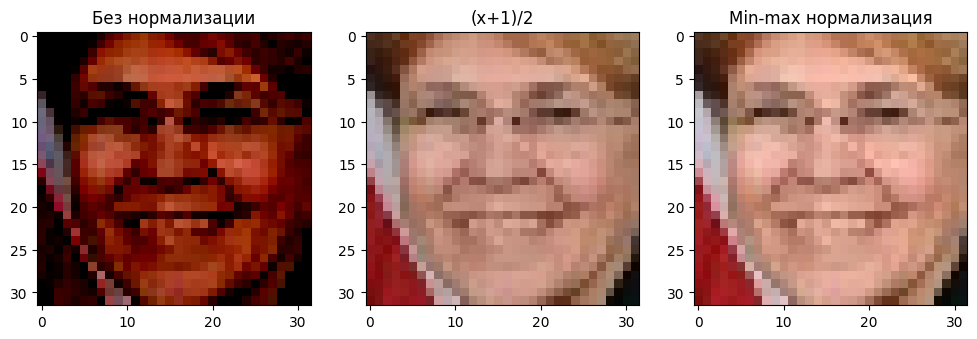

In [83]:
sample = next(gan_generator)
print(f"Shape: {sample.shape}")
print(f"Min value: {sample.min()}")
print(f"Max value: {sample.max()}")
print(f"Mean value: {sample.mean()}")
print(f"Value range: [{sample.min():.2f}, {sample.max():.2f}]")

# Попробуйте разные способы отображения
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(sample[0])
plt.title("Без нормализации")

plt.subplot(1, 3, 2)
plt.imshow((sample[0] + 1) / 2)
plt.title("(x+1)/2")

plt.subplot(1, 3, 3)
plt.imshow((sample[0] - sample[0].min()) / (sample[0].max() - sample[0].min()))
plt.title("Min-max нормализация")

plt.show()

## Задание 2. Обучение DCGAN

В этом задании вам нужно просто запустить обучение GAN. С указанными параметрами оно займет около часа.

Предварительно заманутите Google Drive, для сохранения промежуточных результатов и весов модели.

In [84]:
# Для того, чтобы сохранять прогресс и веса модели, будем использовать google drive -- так модель не потеряется
# и в случае отключения Colab в сможете продолжить обучение.
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [85]:
output = Path("/content/drive/My Drive/gan_utk_32")
output.mkdir(exist_ok=True)
(output / "model").mkdir(exist_ok=True)

gan = DCGAN(image_size=IMAGE_SIZE, num_channels=3, output_path=output,
           z_dim=100, D_h_size=128, G_h_size=128)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
# если при запуске обучения вы видите "WARNING:tensorflow:Entity <bound method DCGAN.train_step ...",
# раскомментируйте строчку ниже, установите пакет и рестартните runtime
# это временный баг в tf из-за изменения версии gast
#! pip install 'gast==0.2.2'

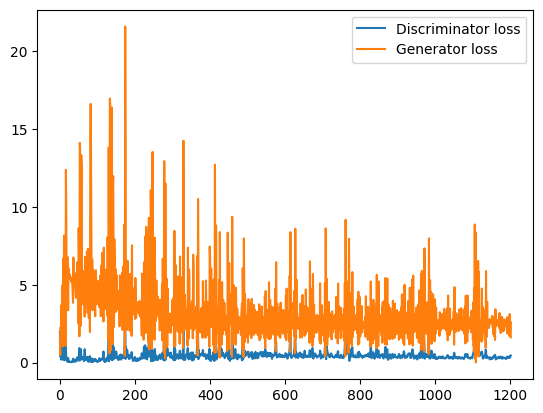

<Figure size 640x480 with 0 Axes>

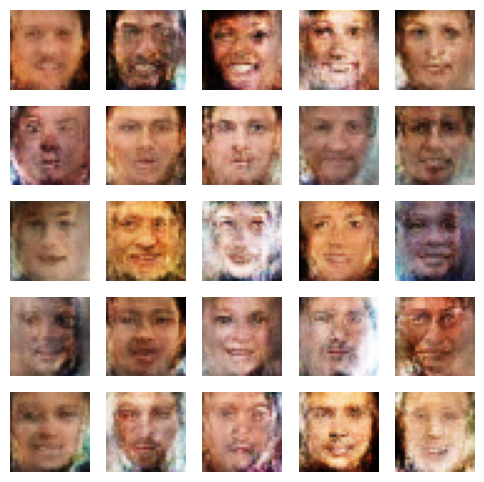


10000/10000
Time elapsed from start 690.1470010280609 sec
Finished. Time elapsed from start 690.1470186710358 sec


In [87]:
images = list(output.glob("*.png"))
if images:
    iters = list(map(lambda x: int(x.name.split(".")[0]), images))
    last_iter = sorted(iters)[-1]
    gan.start_iteration = last_iter
    print(f"Resuming model from {last_iter} iteration")

# Переопределяем output_path
gan.output_path = Path("/content/drive/My Drive/gan_utk_32/")

# Построим модель
sample_batch = next(gan_generator)
_ = gan.generator(tf.random.normal([1, gan.z_dim]))
_ = gan.discriminator(sample_batch[:1])

# ============ ИСПРАВЛЕНИЕ ЗДЕСЬ ============
# Строим всю модель DCGAN
dummy_input = tf.random.normal([1, gan.z_dim])
_ = gan(dummy_input)  # Вызываем модель как функцию
# ===========================================

# Просто исправляем метод train прямо в объекте
def train_fixed(self, dataset, num_iters=2000, show_every=25):
    import time
    import matplotlib.pyplot as plt
    from IPython import display

    start = time.time()
    iters = self.start_iteration

    for image_batch in dataset:
        print(".", end='')
        gen_loss, disc_loss = self.train_step(image_batch)

        self.disc_loss_hist.append(disc_loss.numpy())
        self.gen_loss_hist.append(gen_loss.numpy())

        if iters % show_every == 0:
            display.clear_output(wait=True)
            plt.figure()
            plt.plot(self.disc_loss_hist, label="Discriminator loss")
            plt.plot(self.gen_loss_hist, label="Generator loss")
            plt.legend(loc="best")
            plt.figure()
            self.save_imgs(f"{iters}")

            # ИСПРАВЛЕНО: добавляем .weights.h5
            self.save_weights(str(self.output_path / "model" / "dcgan_model.weights.h5"))

            print(f"\n{iters}/{num_iters}")
            print(f'Time elapsed from start {time.time() - start} sec')

        iters += 1
        if iters > num_iters:
            print(f'Finished. Time elapsed from start {time.time() - start} sec')
            return

# Заменяем метод train
gan.train = train_fixed.__get__(gan, DCGAN)

# Запускаем
gan.train(gan_generator, 10000, 50)

После того как модель обучена, можно посмотреть какие лица она научилась генерировать!

In [88]:
def generate_data(latent_vector, generator):
    """
    Для того чтобы сгенерировать объект нам нужен генератор и латентный вектор
    """
    gen_imgs = generator(latent_vector, training=False)
    gen_imgs = 0.5 * gen_imgs + 0.5
    return gen_imgs

Вектор:  [ 1.1701064  -1.133196    0.2407819  -0.7713299   0.40484324  0.99402845
 -0.48897564 -0.499669   -1.3401977  -1.0940397 ]


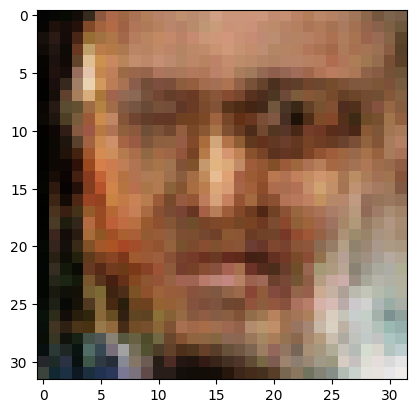

In [89]:
v1 = tf.random.normal([1, 100]) # случайный вектор
print("Вектор: ", v1.numpy()[0, :10]) # распечатаем 10 первых элементов
_ = plt.imshow(generate_data(v1, gan.generator)[0]) # сгенерированное лицо, попробуйте сгенерировать несколько.
                                                    # они должны получаться достаточно реалистичными

## Задание 3. Поиск вектора улыбки

В этом задании вам предстоит найти “вектор улыбки” и доказать что он таковым является.

Что это означает? Как мы уже знаем, GAN генерирует данные из случайных векторов из определенного распределения. Такие вектора образуют латентное пространство. Напомню аналогию с бегунками в компьютерной игре - в этом случае латентное пространство задается всеми положениями бегунков, которым соответствуют реалистичные лица.

В нашем случае GAN тоже выучил нечто подобное, ведь ему хватает 100 чисел, чтобы создать лицо -- это и есть его бегунки. Можно увидеть, что среди сгенерированных лиц имеются лица с улыбкой и без. А значит можно предположить, что какое-то определенное расположение этих бегунков (определенные значения латентного вектора) отвечают за улыбку. Тогда можно считать, что есть определенная комбинация этих 100 чисел, прибавив которую к вектору соответствующему нейтральному лицу можно получить это же лицо, только с улыбкой. Эти 100 чисел мы и называем “вектор улыбки”.


In [90]:
# вспомогательный код
def generate_many(generator, n):
    vis_noise = np.random.normal(0, 1, (n, 100)).astype(np.float32)
    gen_imgs = generator(vis_noise, training=False)
    show_many(gen_imgs, "Generated images")
    return vis_noise

def show_many(images, title=""):
    w = h = int(np.sqrt(len(images)))
    images = (np.clip(images, -1, 1) + 1.) / 2.

    fig, axs = plt.subplots(w, h, figsize=(w, h))
    if title != "":
        fig.suptitle(title)

    cnt = 0
    for i in range(h):
        for j in range(w):
            axs[i, j].imshow(images[cnt, :, :, :])
            axs[i, j].set_title(f"{cnt}")
            axs[i, j].axis('off')
            cnt += 1
    plt.subplots_adjust(wspace=.5)


### a) Интерполяция
Используйте функцию show_interpolation для отображения превращения лица соответствующего латентному вектору `v_1` в лицо, соответствующее `v_2`. Вектора определите случайно из правильного распределения.



In [91]:
def show_interpolation(v_1, v_2, generator, n=20):
    """
    Превращает v_1 в v_2 за n шагов, изображая
    картинки соответствующие промежуточным векторам

    """
    fig, axs = plt.subplots(1, n, figsize=(n,1))
    for i, alpha in enumerate(np.linspace(0, 1, n)):
        curr_vec = v_1 * (1-alpha) + v_2 * alpha
        image = generate_data(curr_vec, gan.generator)[0]
        axs[i].imshow(image)
        axs[i].axis('off')

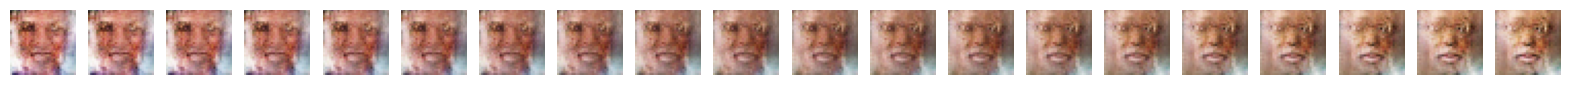

In [94]:
# < YOUR CODE STARTS HERE >
v1 = np.random.normal(0, 1, (1, gan.z_dim)).astype(np.float32)  # Добавьте (1, ...)
v2 = np.random.normal(0, 1, (1, gan.z_dim)).astype(np.float32)  # Добавьте (1, ...)

# < YOUR CODE ENDS HERE >

show_interpolation(v1, v2, gan.generator, n=20)

## b) Поиск вектора улыбки

Придумайте каким образом найти *вектор улыбки* в латентном пространстве и докажите визуально, что это именно он -- превратив нейтрального человека в улыбающегося и наоборот.

*Вам могут пригодится функции generate_many и show-interpolation*

Результат должен получиться похожим на:

<img alt="smile.png" src="https://sun9-51.userapi.com/c857228/v857228713/aea82/t93eL7L3zbU.jpg">  
Если затрудняетесь – ниже есть подсказка. Но обязательно сначала подумайте над задачей сами)

In [ ]:
# < YOUR CODE STARTS HERE >

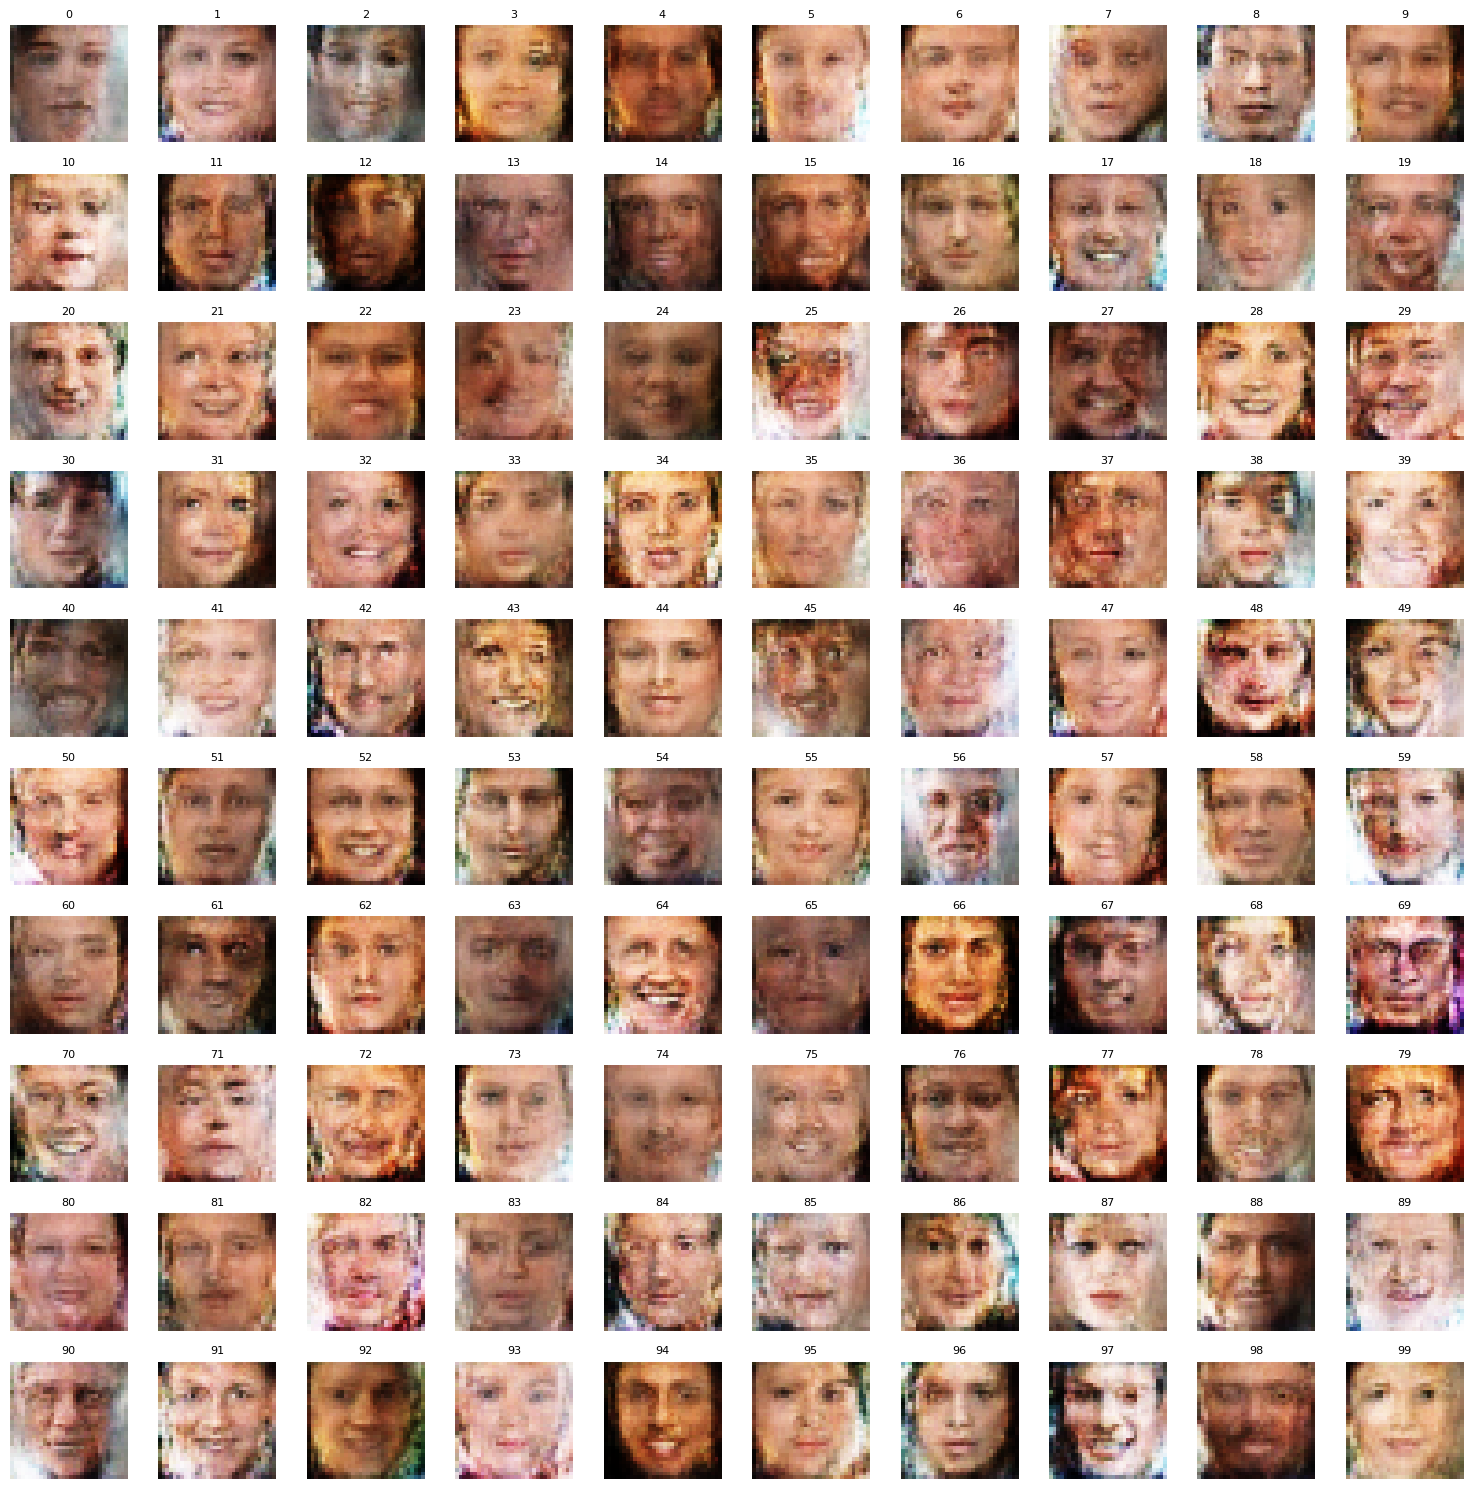

In [95]:
# Сначала сгенерируйте много изображений и получите их латентные векторы
def generate_many(generator, n_samples=100, z_dim=100):
    """
    Генерирует n_samples изображений и возвращает их вместе с латентными векторами
    """
    vectors = np.random.normal(0, 1, (n_samples, z_dim)).astype(np.float32)
    images = generator(vectors, training=False)
    images = (images + 1) / 2  # денормализация в [0, 1]
    return vectors, images.numpy()

# Генерируем 100 изображений
vectors, images = generate_many(gan.generator, n_samples=100, z_dim=gan.z_dim)

# Визуализируем их, чтобы выбрать улыбающиеся и неулыбающиеся
fig, axes = plt.subplots(10, 10, figsize=(15, 15))
for i, ax in enumerate(axes.flat):
    if i < len(images):
        ax.imshow(images[i])
        ax.set_title(f"{i}", fontsize=8)
        ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
# поиск вектора улыбки

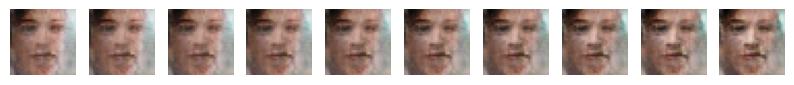

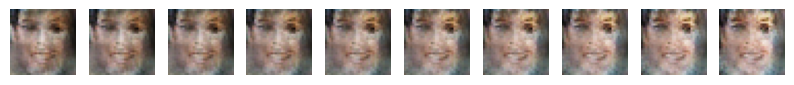

In [102]:
# Номера лиц без улыбки (выберите сами из сгенерированных)
neutral_indices = [0, 1, 3, 5, 7, 12, 15, 18, 21, 25]  # ЗАМЕНИТЕ на свои
# Номера лиц с улыбкой (выберите сами из сгенерированных)
smile_indices = [2, 4, 6, 8, 10, 14, 16, 19, 22, 28]    # ЗАМЕНИТЕ на свои

neutral_vectors = vectors[neutral_indices]
smile_vectors = vectors[smile_indices]

# Вычисляем средние векторы
mean_neutral = np.mean(neutral_vectors, axis=0)
mean_smile = np.mean(smile_vectors, axis=0)

# Вектор улыбки = разница между средним улыбающихся и средним нейтральных
smile_vector = mean_smile - mean_neutral

# ============ ИСПРАВЛЕНИЕ ЗДЕСЬ ============
# Добавляем размерность батча
test_neutral = neutral_vectors[0:1]  # используем срез, а не индекс
test_smile = test_neutral + smile_vector * 1.5
# ===========================================

# Показываем интерполяцию от нейтрального к улыбающемуся
show_interpolation(test_neutral, test_smile, gan.generator, n=10)

# Демонстрация: убираем улыбку
test_smile2 = smile_vectors[0:1]  # тоже используем срез
test_neutral2 = test_smile2 - smile_vector * 1.5
show_interpolation(test_smile2, test_neutral2, gan.generator, n=10)

In [ ]:
# нейтральный человек ------> с улыбкой

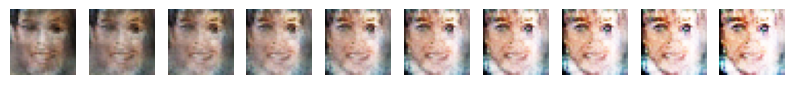

In [106]:
coefficient = 5.0  # или 4.0, или 5.0

test_smile2 = smile_vectors[0:1]
test_neutral2 = test_smile2 - smile_vector * coefficient

show_interpolation(test_smile2, test_neutral2, gan.generator, n=10)

Коэффициент: 2.0
Коэффициент: 2.5
Коэффициент: 3.0
Коэффициент: 3.5
Коэффициент: 4.0
Коэффициент: 5.0
Коэффициент: 6.0
Коэффициент: 7.0
Коэффициент: 8.0
Коэффициент: 9.0
Коэффициент: 10.0


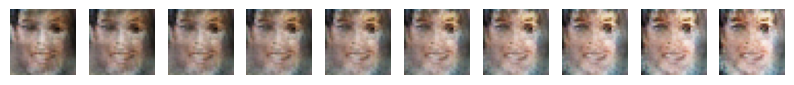

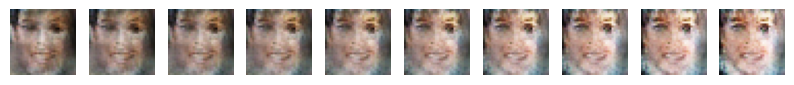

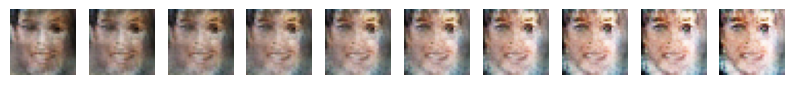

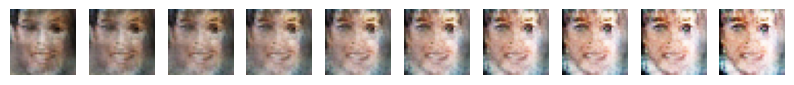

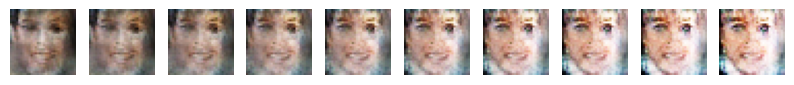

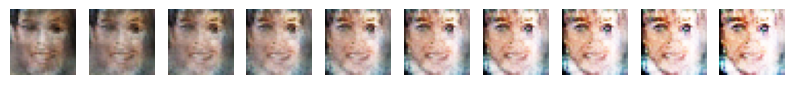

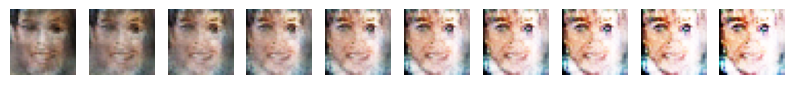

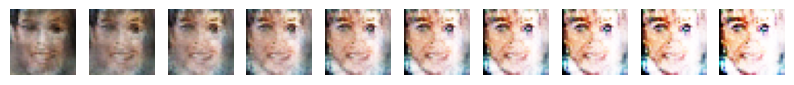

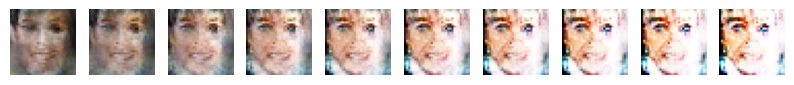

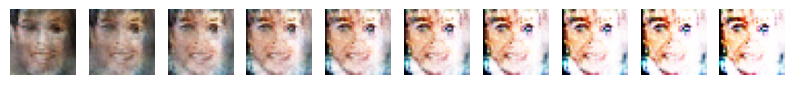

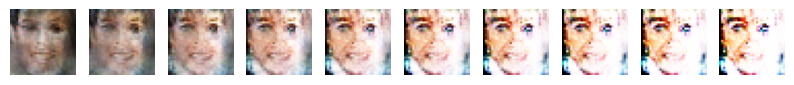

In [110]:
# человек с улыбкой ------> нейтральный
for coef in [2.0, 2.5, 3.0, 3.5, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0]:
    print(f"Коэффициент: {coef}")
    test_neutral2 = test_smile2 - smile_vector * coef
    show_interpolation(test_smile2, test_neutral2, gan.generator, n=10)

In [ ]:
# < YOUR CODE ENDS HERE >

In [ ]:
#@title Подсказка (спойлер). Нажмите дважды чтобы открыть { display-mode: "form" }
"""
Для выполнения задания воспользуйтесь функцией generate_many
для того чтобы получить 100 сгенерированных изображений
и соответствующие им вектора (их вернет эта функция).

Вы увидите, что лица пронумерованы и среди них есть лица
с улыбкой. выберите около 10 лиц с улыбкой и 10 без,
запомните их номера. Затем посчитайте средний вектор
лица без улыбки и средний вектор лица с улыбкой. Разница
между ними и будет искомым вектором.
"""


## Бонусное задание

Есть несколько вариантов выполнения бонусного задания, оно необязательное, но поможет вам глубже погрузиться в тему:

1.  Как вы обратили внимание, мы работали с картинками очень маленького разрешения  -- 32x32. Это было сделано для ускорения вычислений. Попробуйте обучить модель 64x64. Это может занять гораздо больше времени. У авторов https://github.com/znxlwm/pytorch-MNIST-CelebA-GAN-DCGAN на обучение ушло около 4 часов. Вы можете использовать датасет, [CelebA](http://mmlab.ie.cuhk.edu.hk/projects/CelebA.html) использованный ими. Или https://data.vision.ee.ethz.ch/cvl/rrothe/imdb-wiki/ .
2.  Проявите креатив. Обучите GAN для новых данных. Например, для генерации [мордочек кошек](https://ajolicoeur.wordpress.com/cats/) (по ссылке несколько практических рекомендаций по обучению GAN вообще и некоторые более новые архитектуры), [персонажей аниме](https://github.com/Mckinsey666/Anime-Face-Dataset) и тд. Вы можете изменять имеющийся код (делайте это ниже) или использовать сторонние реализации при обязательном цитировании источников.
